# **Setup OBLW-05:  Zscore Generation**

## **0. Setup**

In [1]:
# Load packages
using Revise
using NeuralLongwave
using CairoMakie

In [2]:
# Build together raw data dir
RAW_DIR = raw_data_dir("OBLW", "02_offline", "01_training_data")

# Choose subset of ICs (1:3 are training, 4 is validation)
ICs = 1:3

# Define to be fitted output forms
FORMS = (; 
    linear = LinearOutput(),            # a + b * T
    planck = PlanckOutput()             # a + b * T^4
);

## **1. Calculation**

In [4]:
# Load column IO data derived in 03_column_io_traininig.ipynb
column_io = NeuralLongwave.load(; dir = column_io_dir("OBLW", "training_data"), file = "column_io.jld2")

# Calculate output form coefficients by fitting
coeffs = (; 
    linear = fit_coeffs(LinearOutput(), column_io),
    planck = fit_coeffs(PlanckOutput(), column_io)
);

In [5]:
# Derive zscore stats
zs = derive_zscore(;
    column_io = column_io,
    coeffs    = coeffs,
    scheme    = "OBLW",
    unit      = "default",
    fit_forms = FORMS,
);

┌ Info: Info file written to c:\Code\NeuralLongwave.jl\data\zscore\OBLW\default\info.toml!
└ @ NeuralLongwave c:\Code\NeuralLongwave.jl\src\utils\io.jl:227
┌ Info: Zscore statistics OBLW_default stored at c:\Code\NeuralLongwave.jl\data\zscore\OBLW\default!
└ @ NeuralLongwave c:\Code\NeuralLongwave.jl\src\data\derive_zscore.jl:63


## **2. Histograms**

### 2.1. Histograms IO

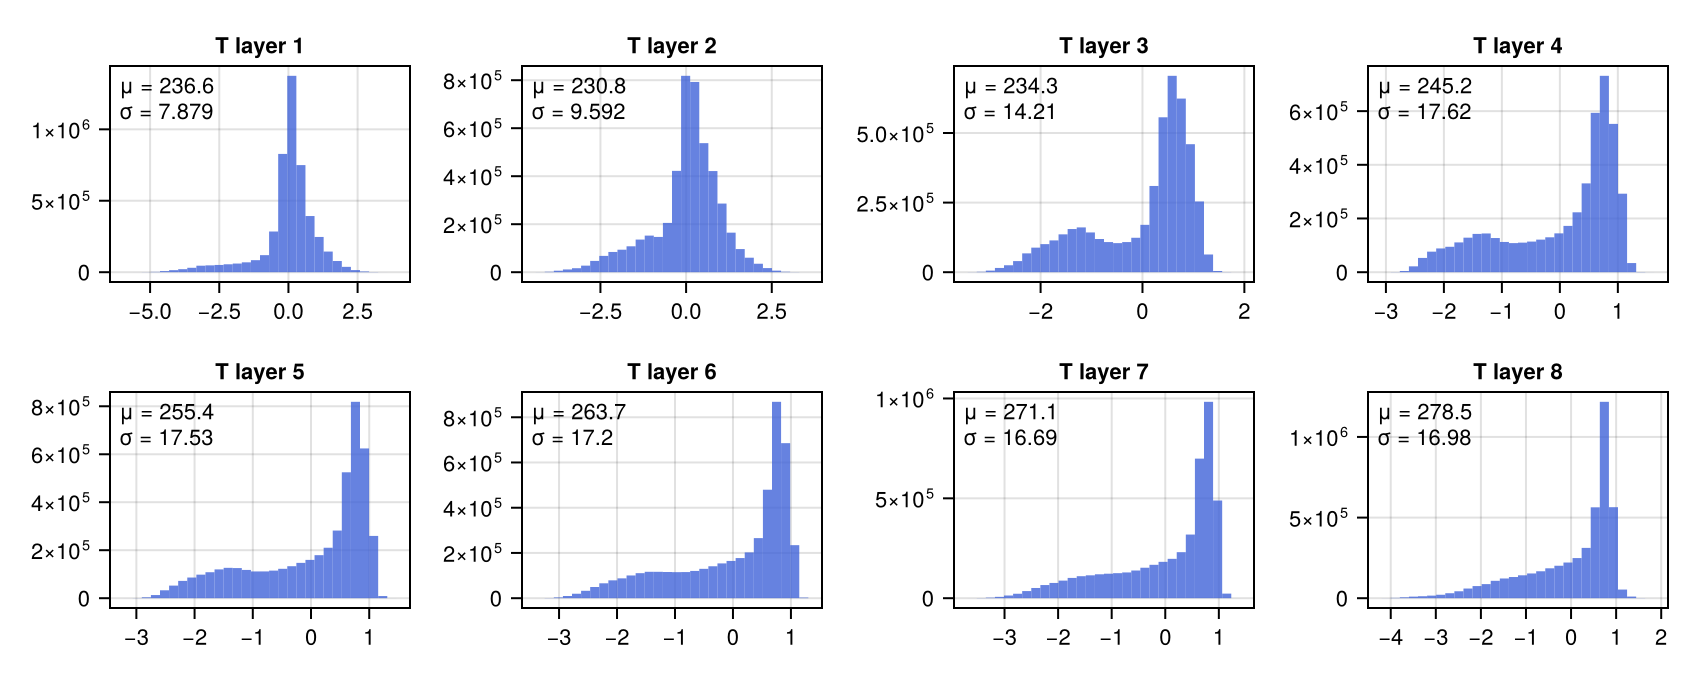

In [27]:
# Temperature
h_T = plot_hist(column_io.fields, zs.fields, (:T))  

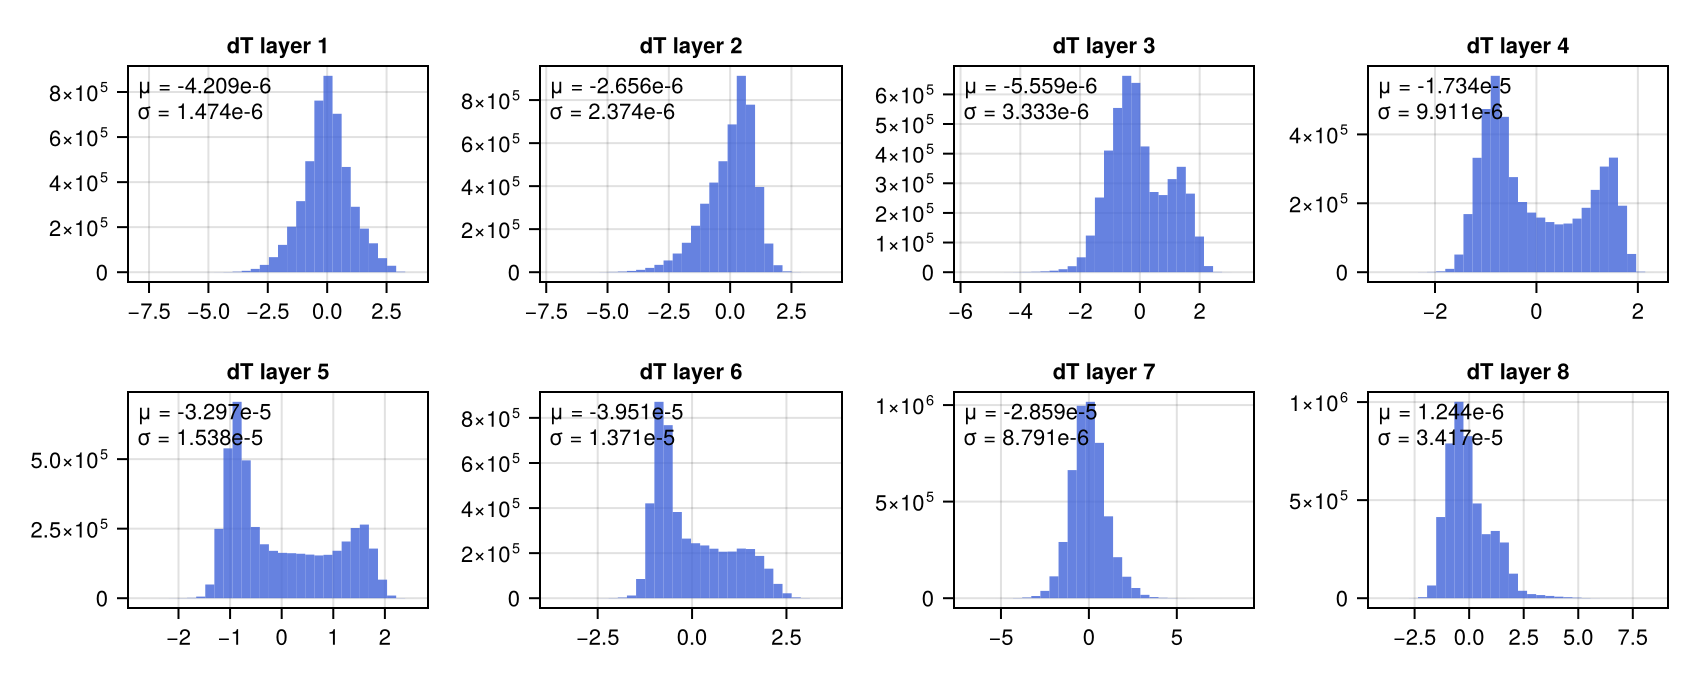

In [28]:
# Temperature tendencies
h_dT = plot_hist(column_io.fields, zs.fields, (:dT))  

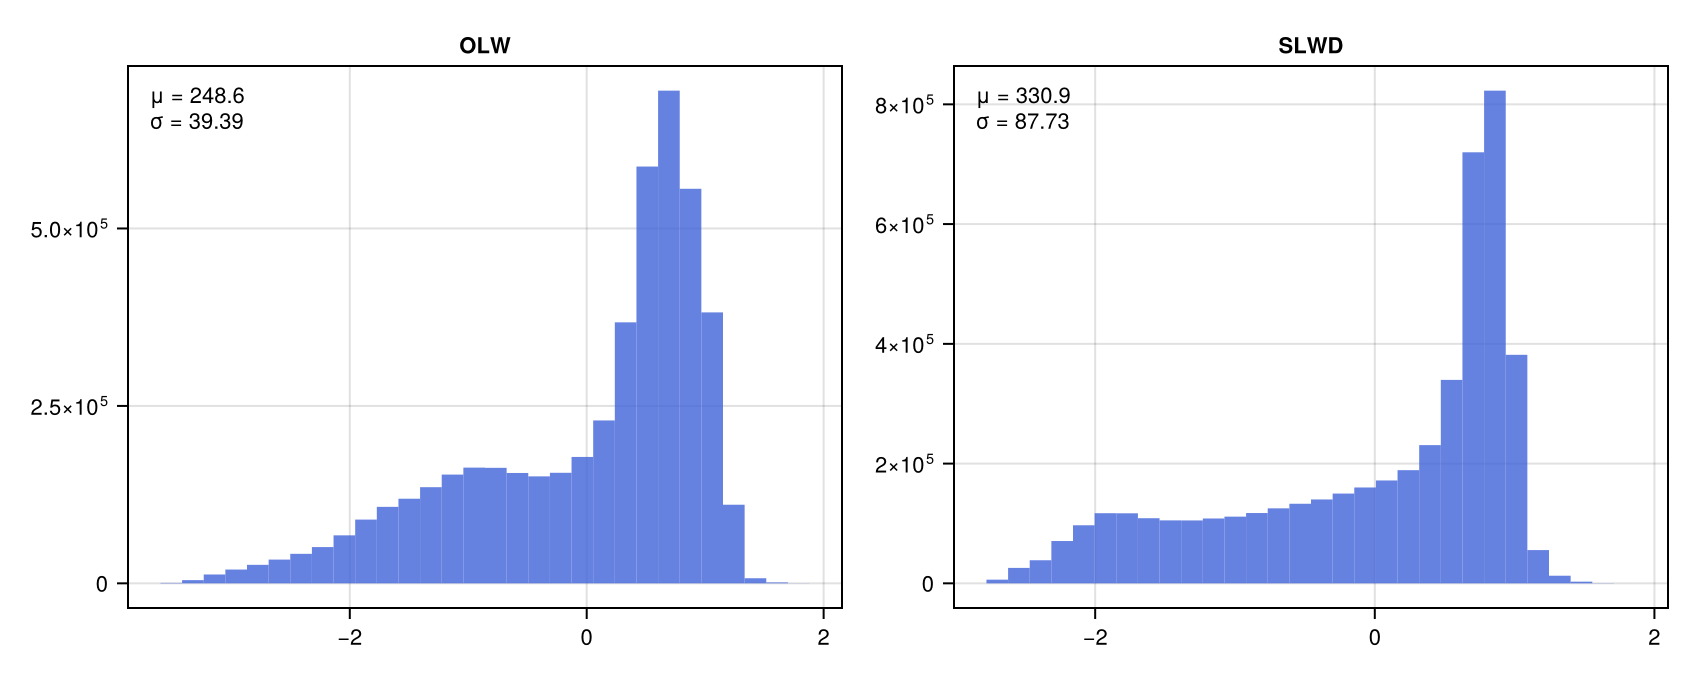

In [29]:
# Fluxes
h_flux = plot_hist(column_io.fields, zs.fields, (:olw, :slwd))  

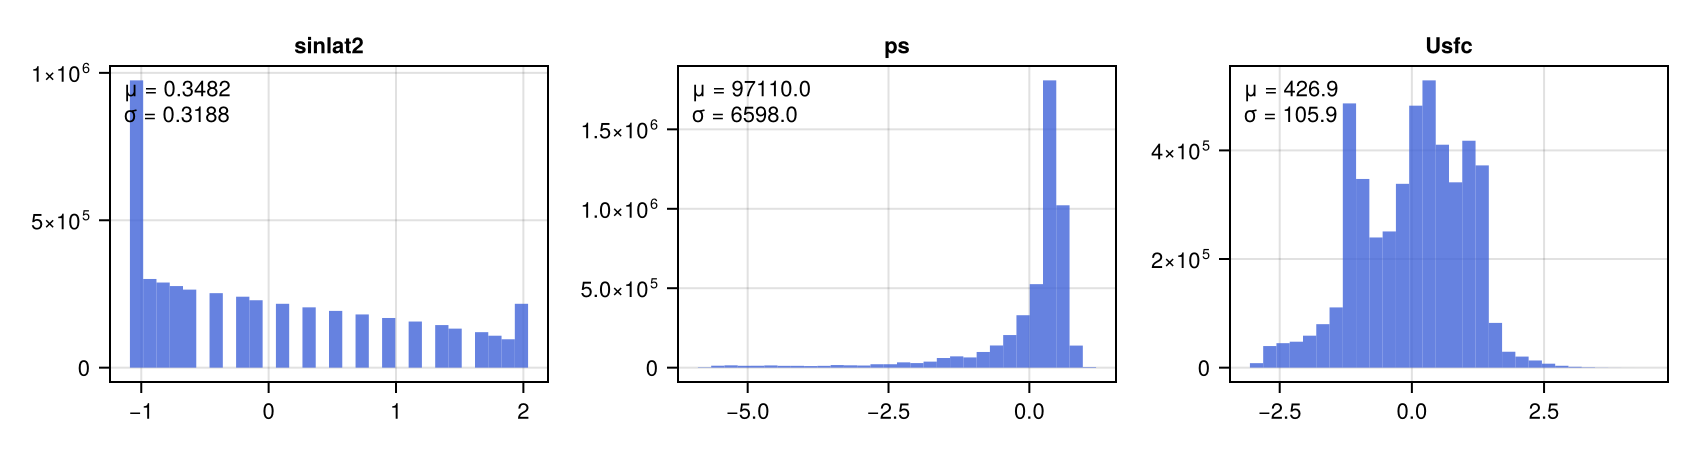

In [30]:
# Input scalars
h_scalar = plot_hist(column_io.fields, zs.fields, (:sinlat2, :ps, :Usfc))  

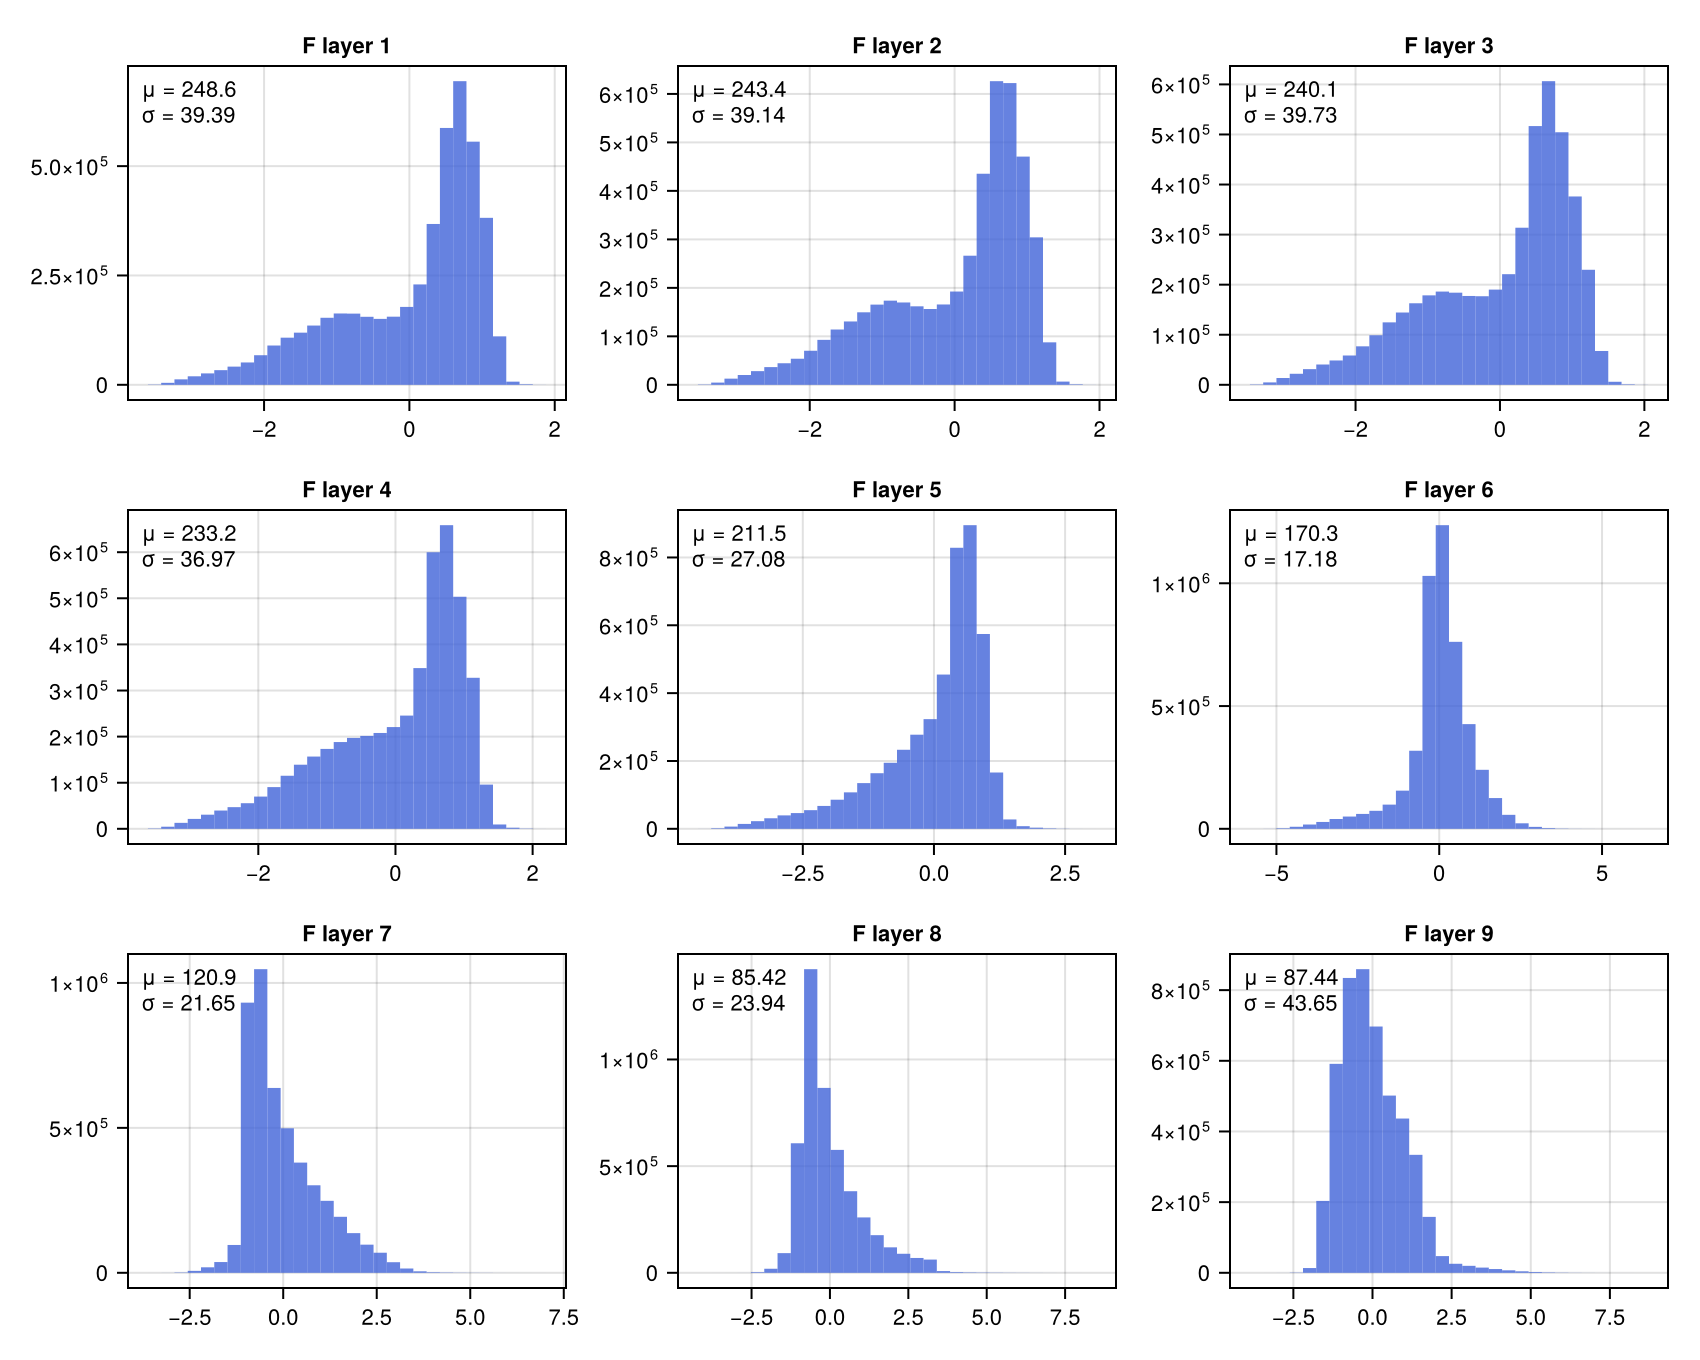

In [43]:
# Net fluxes at layer interfaces
h_net_fluxes = plot_hist(column_io.fields, zs.fields, (:F), style=(;ncols=3)) 

### 2.2. Histograms Output form Coefficients

#### 2.2.1. Temperature

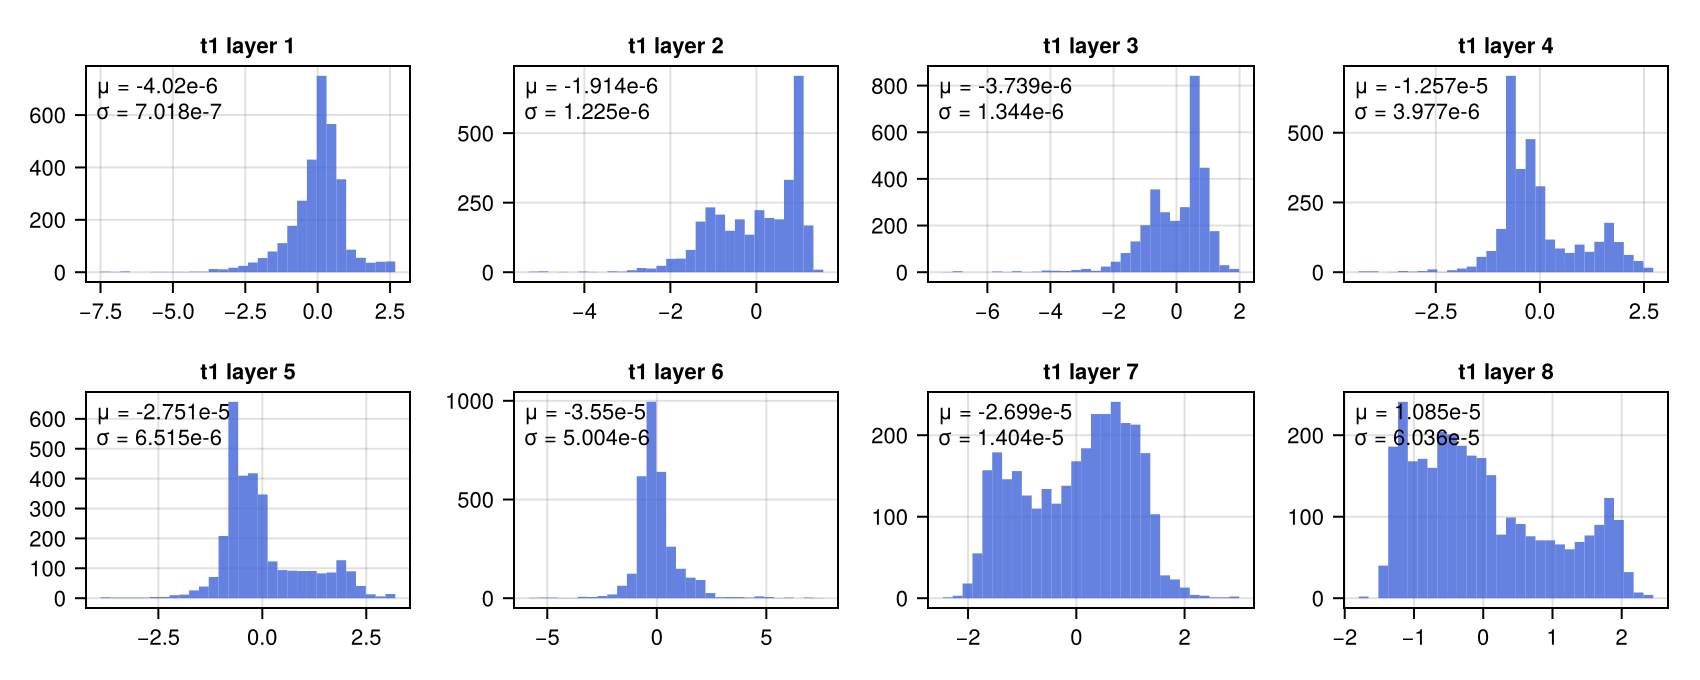

In [32]:
# Linear: Temperature, constant terms
h_t1_linear =plot_hist(coeffs.linear.coeffs, zs.linear, (:t1))

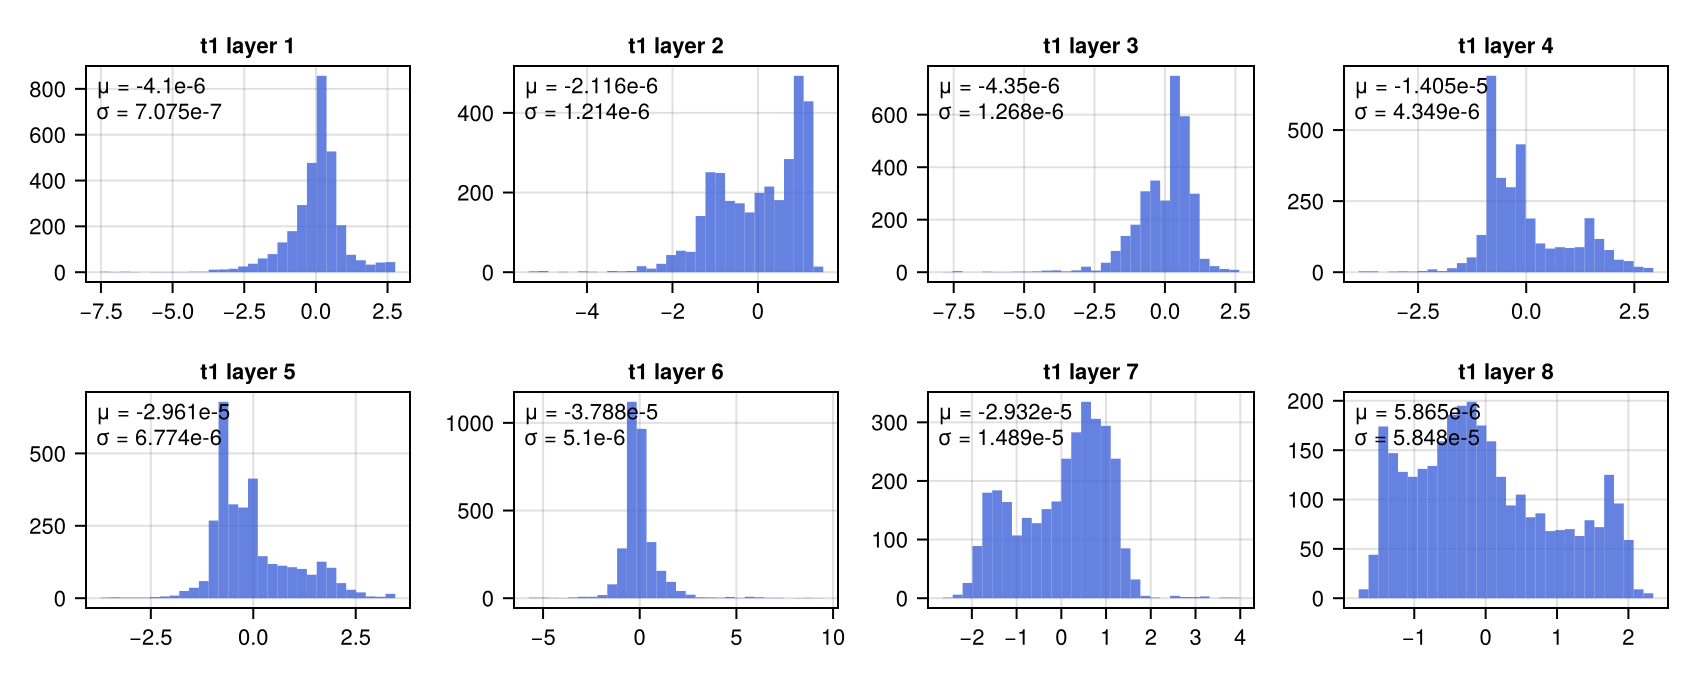

In [33]:
# Planck: Temperature, constant terms
h_t1_planck =plot_hist(coeffs.planck.coeffs, zs.planck, (:t1))

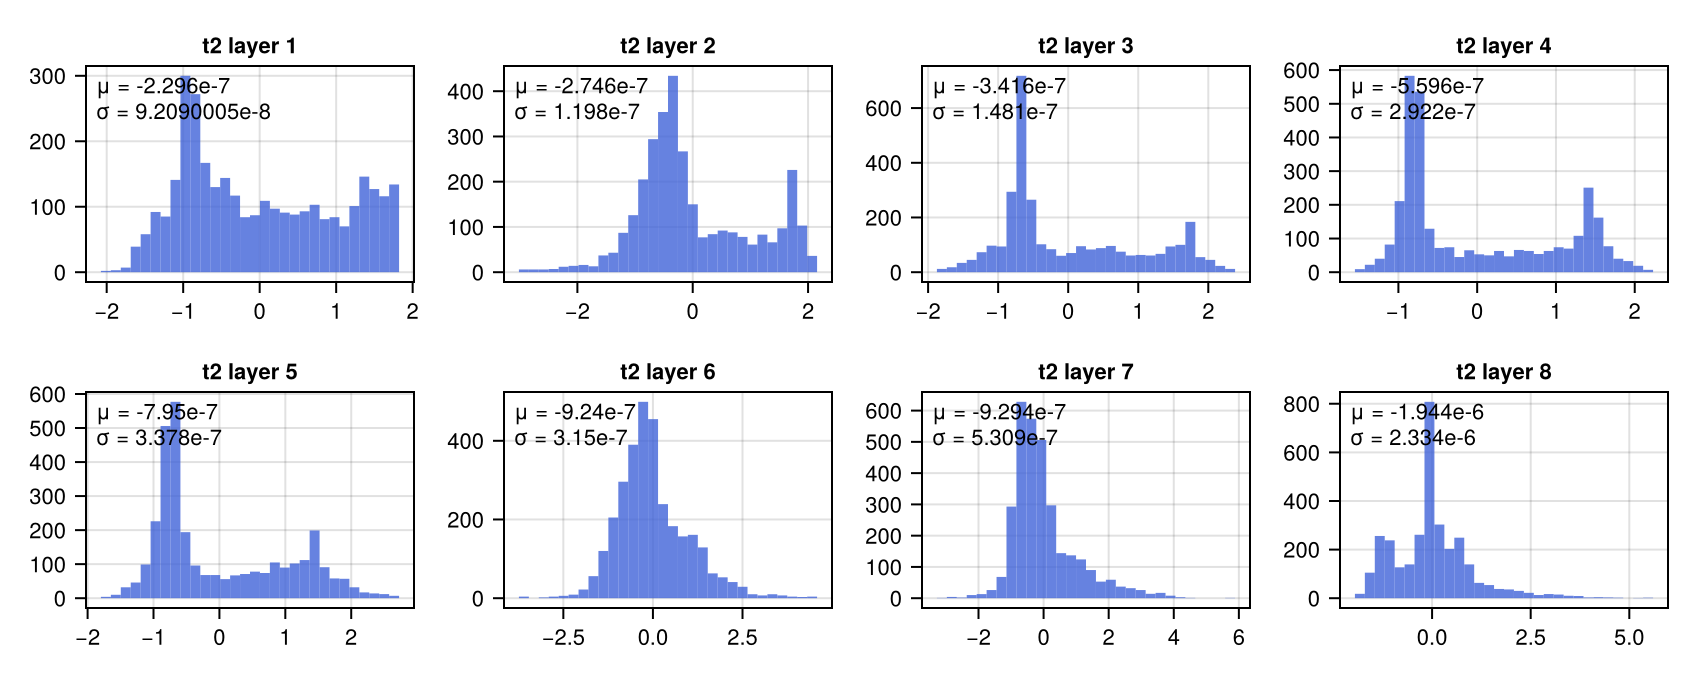

In [44]:
# Linear: Temperature, linear terms
h_t2_linear =plot_hist(coeffs.linear.coeffs, zs.linear, (:t2))

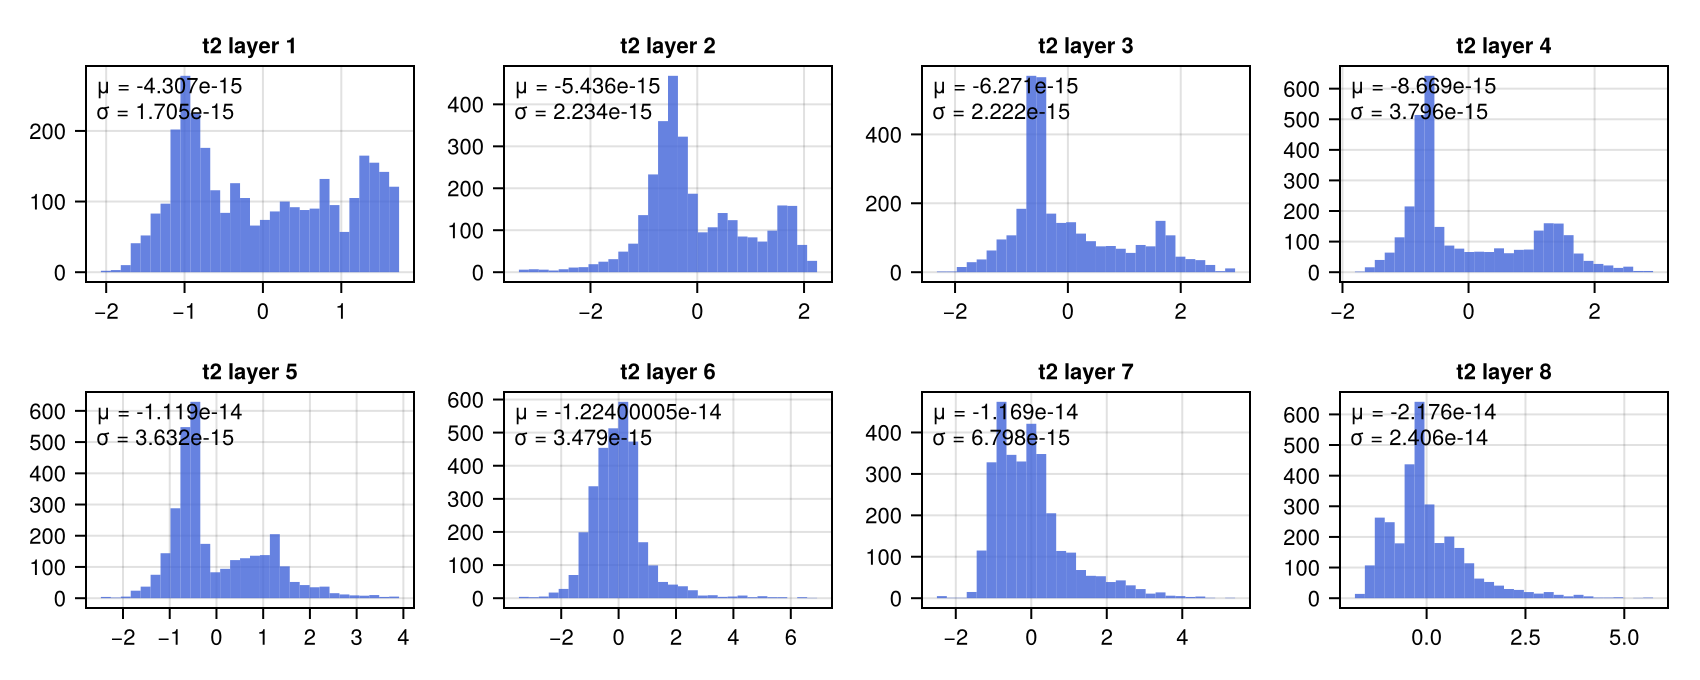

In [35]:
# Planck: Temperature, linear term
h_t2_planck =plot_hist(coeffs.planck.coeffs, zs.planck, (:t2))

#### 2.2.2. Fluxes

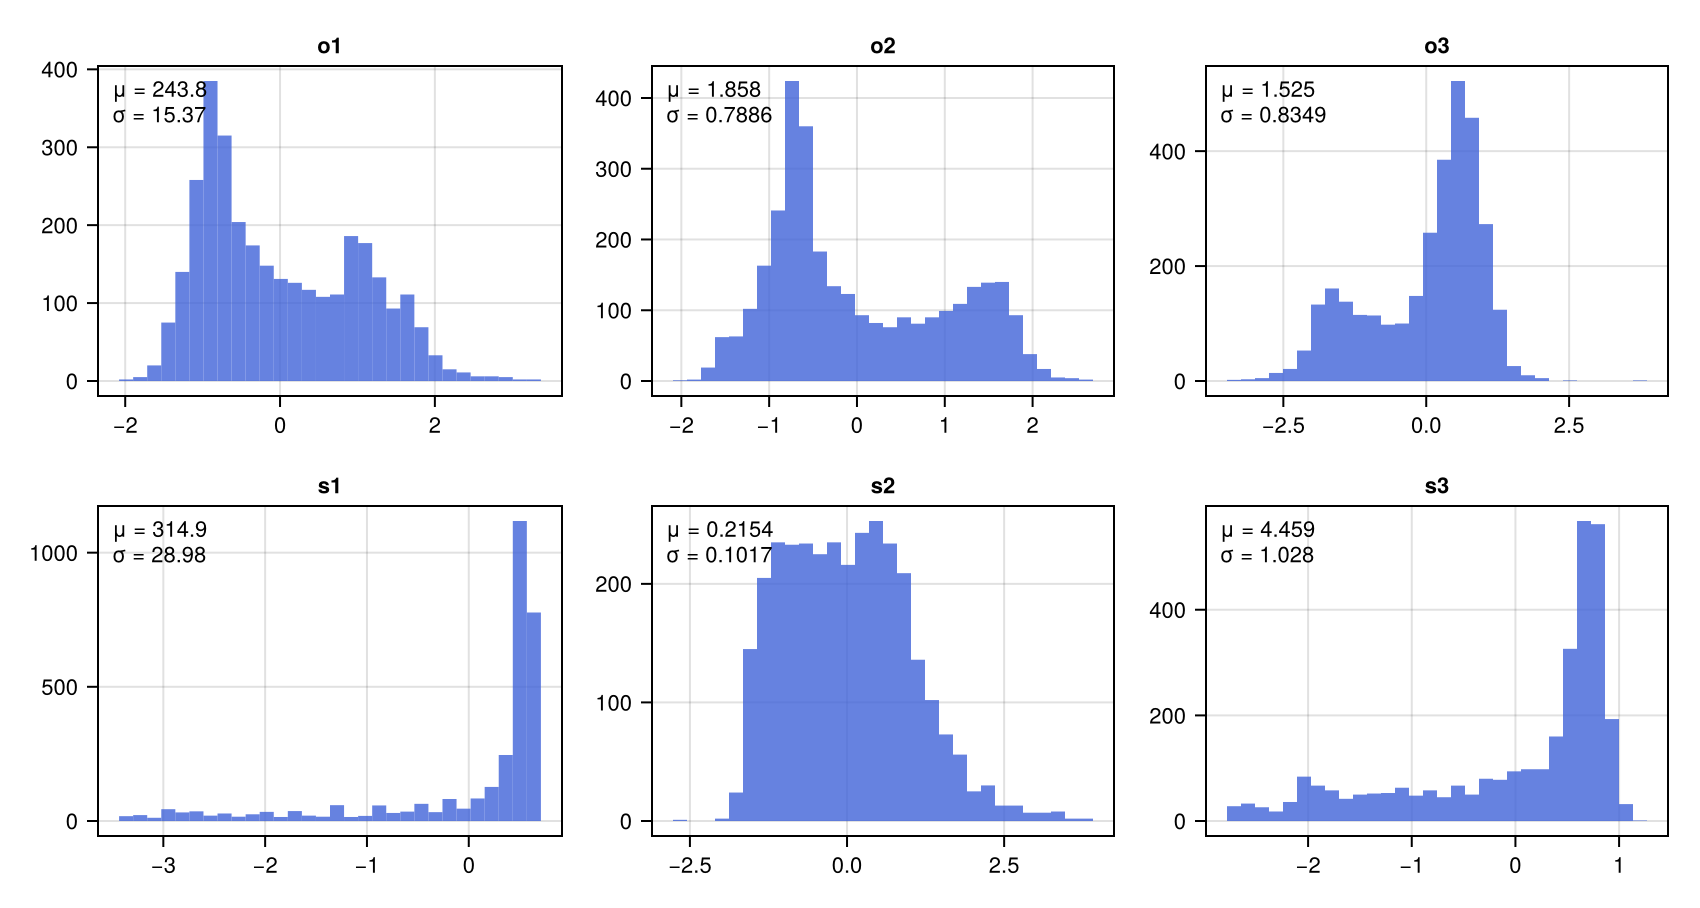

In [45]:
# Linear: Fluxes
h_fluxes_linear =plot_hist(coeffs.linear.coeffs, zs.linear, (:o1, :o2, :o3, :s1, :s2, :s3), style=(;ncols=3))

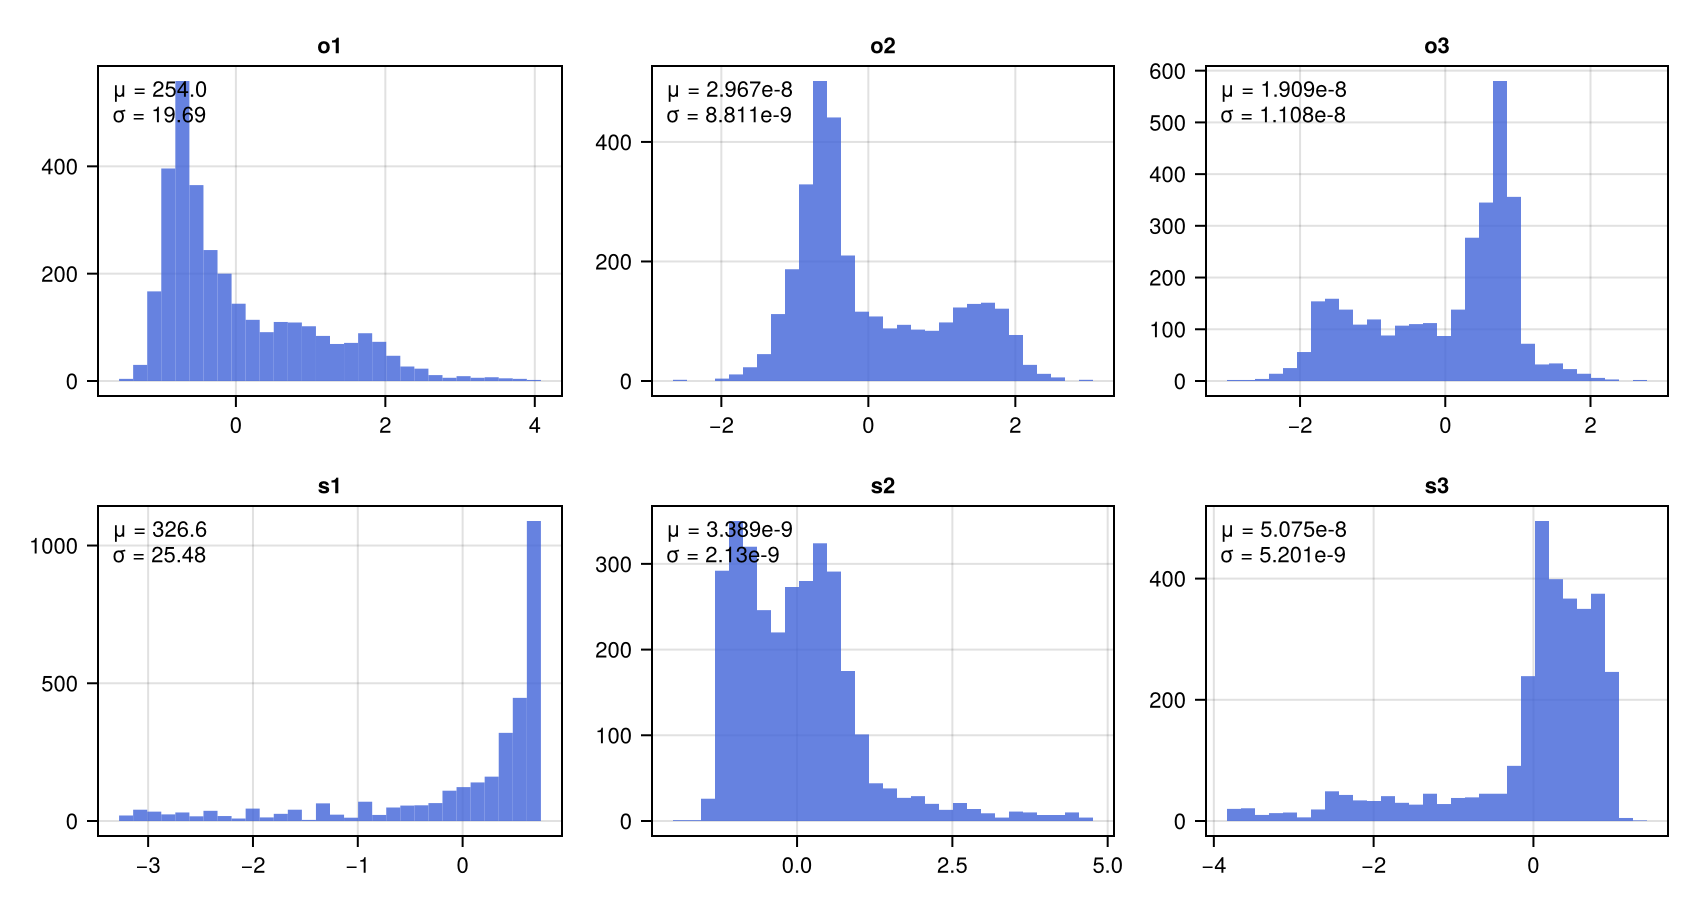

In [46]:
# Planck: Fluxes
h_fluxes_planck =plot_hist(coeffs.planck.coeffs, zs.planck, (:o1, :o2, :o3, :s1, :s2, :s3), style=(;ncols=3))

### 2.3. Save Plots

In [38]:
# Create dir
dir = prepare_out_dir(zscore_dir("OBLW", "default"); name = "plots_distribution", overwrite=true);

In [47]:
# Save IO histograms
save_figure(h_T,            joinpath(dir, "hist_T.png"))
save_figure(h_dT,           joinpath(dir, "hist_dT.png"))
save_figure(h_flux,         joinpath(dir, "hist_flux.png"))
save_figure(h_scalar,       joinpath(dir, "hist_scalar.png"));
save_figure(h_net_fluxes,   joinpath(dir, "hist_net_fluxes.png"));

In [48]:
# Save OF coefficients histograms
save_figure(h_t1_linear,        joinpath(dir, "hist_t1_linear.png"))
save_figure(h_t1_planck,        joinpath(dir, "hist_t1_planck.png"))
save_figure(h_t2_linear,        joinpath(dir, "hist_t2_linear.png"))
save_figure(h_t2_planck,        joinpath(dir, "hist_t2_planck.png"))

save_figure(h_fluxes_linear,    joinpath(dir, "hist_fluxes_linear.png"))
save_figure(h_fluxes_planck,    joinpath(dir, "hist_fluxes_planck.png"))

"c:\\Code\\NeuralLongwave.jl\\data\\zscore\\OBLW\\default\\plots_distribution\\hist_fluxes_planck.png"